<a href="https://colab.research.google.com/github/ashika-06/Quora-Duplicate-Question-Detection/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install distance
!pip install fuzzywuzzy
!pip install python-Levenshtein
!pip install geopy


---

# **1. Quora Question Pairs: Problem Statement & Analysis**

### **1.1. Problem Statement**

Quora is a platform where millions of people ask and answer questions. A significant challenge for the platform is that users often ask the same question using different phrasings.

* **The Goal:** The task is to identify which questions asked on Quora are **duplicates** of questions that have already been asked.
* **The Limitation of Previous Models:** Before advanced NLP, duplicate detection relied heavily on **Lexical Matching** (exact word overlap). These models fail when two questions have the same meaning but share no common words.
* *Example:* "What is your age?" vs. "How old are you?" (Same meaning, zero shared words).
* *Example:* "What is geology?" vs. "What do you study to read about rocks?"



We need a model that understands **Semantic Similarity**—the actual meaning behind the sentence—rather than just keyword matching.

### **1.2. Real-World Constraints**

1. **Cost of Misclassification:**
* **False Positive (Bad):** Incorrectly flagging a unique question as a duplicate prevents users from getting answers to their specific queries.
* **False Negative (Annoying):** Failing to catch a duplicate clutters the platform with repetitive content.


2. **Latency Requirement:**
* There is **no strict low-latency requirement**. Unlike high-frequency trading or autonomous driving, duplicate detection often happens in batch processing or "near real-time." This allows us to use computationally heavy models (like XGBoost with complex feature engineering or Deep Learning) to maximize accuracy.



### **1.3. Mapping to Machine Learning**

* **Type:** Binary Classification.
* **Input ():** A single data point containing two questions (`question1`, `question2`,`qid_1`,`qid_2`).
* **Output ():** A binary label `is_duplicate`:
* `1`: The questions are duplicates.
* `0`: The questions are not duplicates.



### **1.4. Performance Metric: Log Loss**

While Accuracy measures strict right/wrong predictions, we care about the **certainty** of the prediction. Therefore, we use **Log Loss** (Logarithmic Loss) as our primary metric.

**The Formula:**


**Why is Log Loss critical here?**

1. **Penalizing "Arrogance":** Log Loss applies a heavy penalty if the model is confident but wrong.
* If the model predicts a probability of **0.51** for a duplicate and is wrong, the penalty is small.
* If the model predicts **0.99** (high confidence) and is wrong, the penalty is massive.
* This forces the model to be "calibrated"—it should only output high probabilities when it is truly sure.


2. **Probabilistic Output:** In a real-world system, we might set thresholds (e.g., "Only auto-merge if probability > 90%"). Log Loss optimizes the model to provide these reliable probability scores rather than just binary labels.

We will also use the **Confusion Matrix** to track raw Precision and Recall.

### **1.5. Data Splitting Strategy**

* **Split Ratio:** We will use a **70:30 Random Split** (70% Train, 30% Test).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re


import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
from plotly.subplots import make_subplots


import geopy
import distance
from bs4 import BeautifulSoup
from fuzzywuzzy import fuzz
import nltk
from nltk.corpus import stopwords


try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

print("✅ Environment is healthy and libraries are loaded!")

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c quora-question-pairs

 87% 268M/309M [00:00<00:00, 658MB/s] 
100% 309M/309M [00:00<00:00, 703MB/s]


In [ ]:
!unzip -q quora-question-pairs.zip -d /content/quora_questions

In [ ]:
!unzip -q /content/quora_questions/train.csv.zip -d /content/quora_questions


In [ ]:
import pandas as pd

# Load the CSV into a DataFrame
df = pd.read_csv("/content/quora_questions/train.csv")

print("Number of data points:", df.shape[0])


Number of data points: 404290


In [ ]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0



---

# **2. Exploratory Data Analysis (EDA)**

Before building any models, we must understand the structure and quality of our data.

### **2.1. Basic Statistics & Data Integrity**

* **Dataset Size:** We have **404,290** row entries.
* **Missing Values:** By inspecting the data info, we observe a small issue:
* `question1` has 404,289 non-null values (1 missing).
* `question2` has 404,288 non-null values (2 missing).
* **Action:** Since these are text columns, we will replace these few `NaN` values with empty strings to prevent errors during text processing.



### **2.2. Class Distribution (Target Variable)**

We analyze the `is_duplicate` column to check for data imbalance.

* **Non-Duplicates (0):** ~63.08%
* **Duplicates (1):** ~36.92%
* **Insight:** The dataset is imbalanced but not severely. We have enough positive samples to train a robust model without extreme sampling techniques.


---


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


<Axes: xlabel='is_duplicate'>

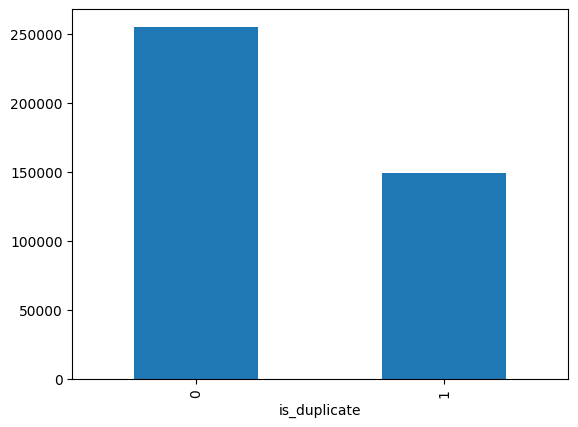

In [ ]:
df.groupby('is_duplicate')['id'].count().plot.bar()

In [ ]:
print("Total number of question pairs for training: {}".format(len(df)))

Total number of question pairs for training: 404290


In [ ]:
print("-> Question pairs are not similar (is_duplicate=0): {:.2f}%".format(
    df['is_duplicate'].value_counts().get(0, 0) / len(df) * 100))

print("-> Question pairs are similar (is_duplicate=1): {:.2f}%".format(
    df['is_duplicate'].value_counts().get(1, 0) / len(df) * 100))


-> Question pairs are not similar (is_duplicate=0): 63.08%
-> Question pairs are similar (is_duplicate=1): 36.92%


In [ ]:
qids = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
unique_qs = len(np.unique(qids))
qs_morethan_onetime = np.sum(qids.value_counts() > 1)
max_repeated = qids.value_counts().max()
q_vals = qids.value_counts().values

print("Total number of Unique Questions are: {}".format(unique_qs))
print("Number of unique questions that appear more than once: {} ({:.2f}%)".format(
    qs_morethan_onetime, qs_morethan_onetime / unique_qs * 100))
print("Max number of times a single question is repeated: {}".format(max_repeated))


Total number of Unique Questions are: 537933
Number of unique questions that appear more than once: 111780 (20.78%)
Max number of times a single question is repeated: 157


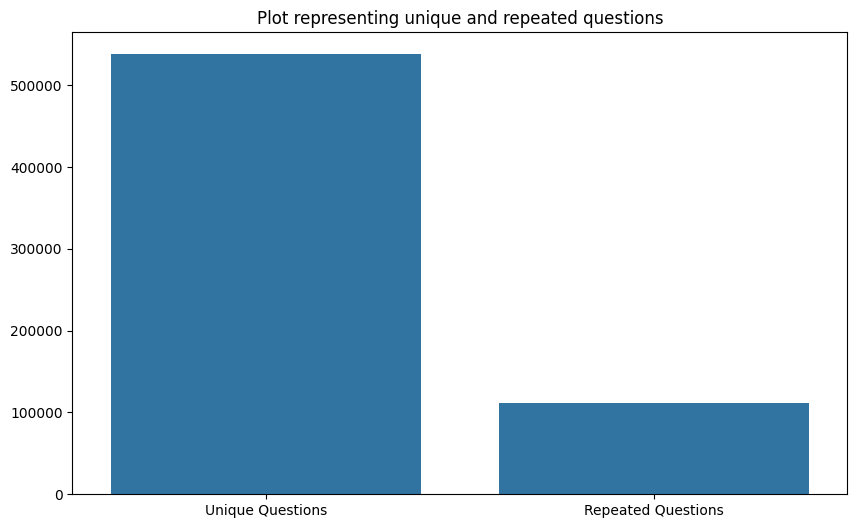

In [ ]:
x = ["Unique Questions", "Repeated Questions"]
y = [unique_qs, qs_morethan_onetime]

plt.figure(figsize=(10,6))
plt.title("Plot representing unique and repeated questions")
sns.barplot(x=x, y=y)
plt.show()

In [ ]:
pair_duplicates = df.groupby(['qid1', 'qid2', 'is_duplicate'])
print("Number of duplicate questions:", df.shape[0] - len(pair_duplicates))


### **2.3. Unique Question Analysis**

Since questions appear in pairs, many unique questions are repeated across different pairs to form new comparisons.

* **Total Unique Questions:** We combine `qid1` and `qid2` to find the total distinct questions.
* **Repeated Questions:** A significant subset of questions does not appear just once. Instead, these questions are reused across multiple pairs (e.g., Question A is compared with B, then with C, then with D). This indicates the presence of "popular" topics where users frequently ask similar variations.
* **Max Occurrence:** One specific question appears in the dataset **157 times** (visible as the solitary bar at the far right of the x-axis).
* **Visualization:** The histogram uses a **log-scale on the y-axis** because the counts vary wildly.
* **The Peak:** The massive bar on the far left shows that the vast majority of questions appear only **1 or 2 times** (count ).
* **The Long Tail:** As we move right, the number of questions drops exponentially. There is a sparse "long tail" of questions that are frequently reused, with a few outliers appearing 60, 100, or even 157 times.



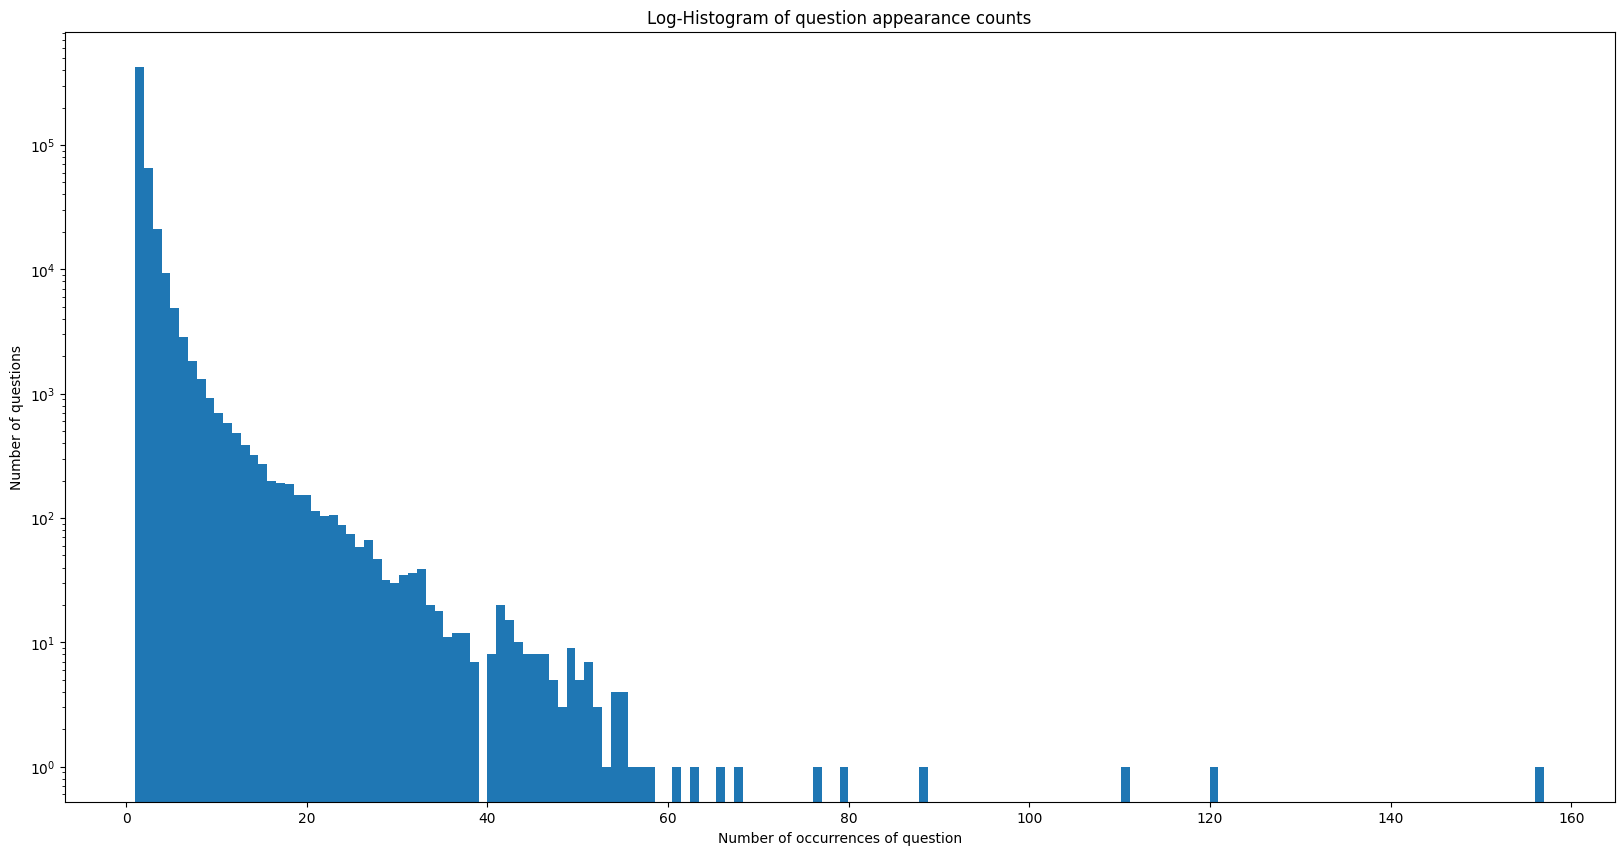

In [ ]:
plt.figure(figsize=(20, 10))
plt.hist(qids.value_counts(), bins=160)
plt.yscale('log', nonpositive='clip')
plt.title("Log-Histogram of question appearance counts")
plt.xlabel("Number of occurrences of question")
plt.ylabel("Number of questions")
plt.show()


In [ ]:
nan_rows = df[df.isnull().any(axis=1)]
print(nan_rows)


            id    qid1    qid2                         question1  \
105780  105780  174363  174364    How can I develop android app?   
201841  201841  303951  174364  How can I create an Android app?   
363362  363362  493340  493341                               NaN   

                                                question2  is_duplicate  
105780                                                NaN             0  
201841                                                NaN             0  
363362  My Chinese name is Haichao Yu. What English na...             0  


In [ ]:
df.fillna('', inplace=True)
nan_rows = df[df.isnull().any(axis=1)]
print(nan_rows)

Empty DataFrame
Columns: [id, qid1, qid2, question1, question2, is_duplicate]
Index: []



---

# **3. Basic Feature Extraction (Before Cleaning)**

Before diving into complex text cleaning and vectorization, we construct a set of **Basic Features** derived from the raw text. These help us understand the structure of the question pairs.

### **3.1. The Features**

We extract **11 features** for every pair:

1. **`freq_qid1`, `freq_qid2`:** The frequency of each question ID in the dataset (how many times does this specific question appear?).
2. **`q1len`, `q2len`:** The total character length of each question.
3. **`q1_n_words`, `q2_n_words`:** The number of words in each question.
4. **`word_common`:** The number of unique words shared between Question 1 and Question 2.
5. **`word_total`:** The total number of unique words in both questions combined.
6. **`word_share`:** The ratio of common words to total words.
* Formula:


7. **`freq_q1+q2`:** The sum of frequencies of both questions.
8. **`freq_q1-q2`:** The absolute difference in frequencies.

### **3.2. Analysis: Violin Plots**

To evaluate if these features are useful, we use **Violin Plots**.

* **What they show:** A Violin plot combines a Box Plot and a Kernel Density Plot. It shows the distribution of the feature for **Class 0 (Non-Duplicate)** vs. **Class 1 (Duplicate)**.
* **Interpretation:**
* **Good Feature:** The distributions (violins) for Class 0 and Class 1 are at different heights or shapes. This means the feature helps separate the classes.
* **Bad Feature:** The distributions **overlap completely**. This means the feature provides no distinguishing power.

---


In [ ]:
import os
import pandas as pd

if os.path.isfile('df_fe_without_preprocessing_train.csv'):
    df = pd.read_csv('df_fe_without_preprocessing_train.csv', encoding='latin1')
else:
    # Frequency features
    df['freq_qid1'] = df.groupby('qid1')['qid1'].transform('count')
    df['freq_qid2'] = df.groupby('qid2')['qid2'].transform('count')

    # Question length features
    df['q1len'] = df['question1'].str.len()
    df['q2len'] = df['question2'].str.len()
    df['q1_n_words'] = df['question1'].apply(lambda row: len(str(row).split()))
    df['q2_n_words'] = df['question2'].apply(lambda row: len(str(row).split()))

    # Word common/shared features
    def normalized_word_common(row):
        w1 = set(map(lambda word: word.lower().strip(), str(row['question1']).split()))
        w2 = set(map(lambda word: word.lower().strip(), str(row['question2']).split()))
        return float(len(w1 & w2))

    df['word_common'] = df.apply(normalized_word_common, axis=1)

    def normalized_word_total(row):
        w1 = set(map(lambda word: word.lower().strip(), str(row['question1']).split()))
        w2 = set(map(lambda word: word.lower().strip(), str(row['question2']).split()))
        return float(len(w1) + len(w2))

    df['word_total'] = df.apply(normalized_word_total, axis=1)

    def normalized_word_share(row):
        w1 = set(map(lambda word: word.lower().strip(), str(row['question1']).split()))
        w2 = set(map(lambda word: word.lower().strip(), str(row['question2']).split()))
        return float(len(w1 & w2) / (len(w1) + len(w2))) if (len(w1) + len(w2)) > 0 else 0.0

    df['word_share'] = df.apply(normalized_word_share, axis=1)

    # Combined frequency features
    df['freq_q1+q2'] = df['freq_qid1'] + df['freq_qid2']
    df['freq_q1-q2'] = abs(df['freq_qid1'] - df['freq_qid2'])

    df.to_csv("df_fe_without_preprocessing_train.csv", index=False)

df.head()


,id,qid1,qid2,question1,question2,is_duplicate,freq_qid1,freq_qid2,q1len,q2len,q1_n_words,q2_n_words,word_common,word_total,word_share,freq_q1+q2,freq_q1-q2
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,1,1,66,57,14,12,10.0,23.0,0.434783,2,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,4,1,51,88,8,13,4.0,20.0,0.200000,5,3
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,1,1,73,59,14,10,4.0,24.0,0.166667,2,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,1,1,50,65,11,9,0.0,19.0,0.000000,2,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,3,1,76,39,13,7,2.0,20.0,0.100000,4,2


In [ ]:
# Compute min lengths
min_q1 = df['q1_n_words'].min()
min_q2 = df['q2_n_words'].min()


print("Minimum length of the questions in question1:", min_q1)
print("Minimum length of the questions in question2:", min_q2)


print("Number of questions with minimum length in question1:", (df['q1_n_words'] == min_q1).sum())
print("Number of questions with minimum length in question2:", (df['q2_n_words'] == min_q2).sum())


In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(1,2,1)
sns.violinplot(x='is_duplicate', y='word_share', data=df[0:])

plt.subplot(1,2,2)
sns.distplot(df[df['is_duplicate'] == 1.0]['word_share'][0:], label="1")
sns.distplot(df[df['is_duplicate'] == 0.0]['word_share'][0:], label="0")
plt.legend()
plt.show()

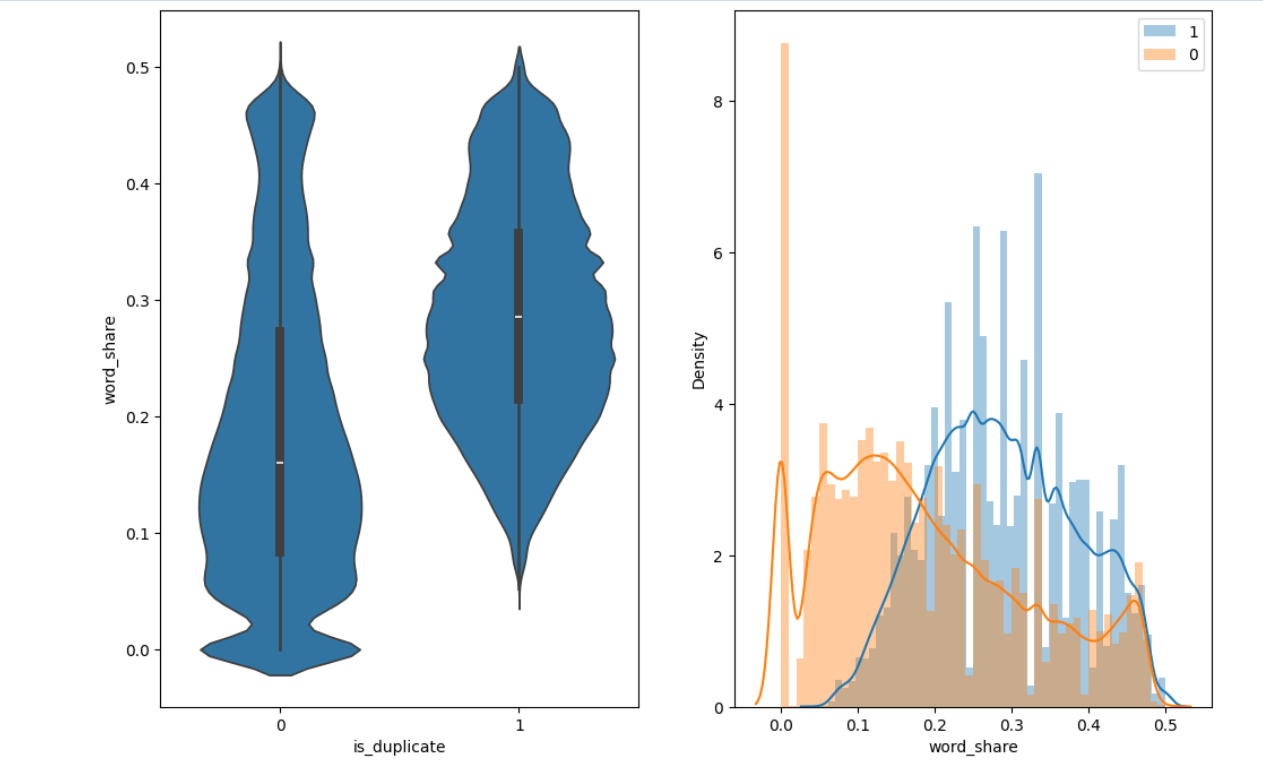

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(1,2,1)
sns.violinplot(x='is_duplicate', y='word_common', data=df[0:])

plt.subplot(1,2,2)
sns.distplot(df[df['is_duplicate'] == 1.0]['word_common'][0:], label="1")
sns.distplot(df[df['is_duplicate'] == 0.0]['word_common'][0:], label="0")
plt.legend()
plt.show()

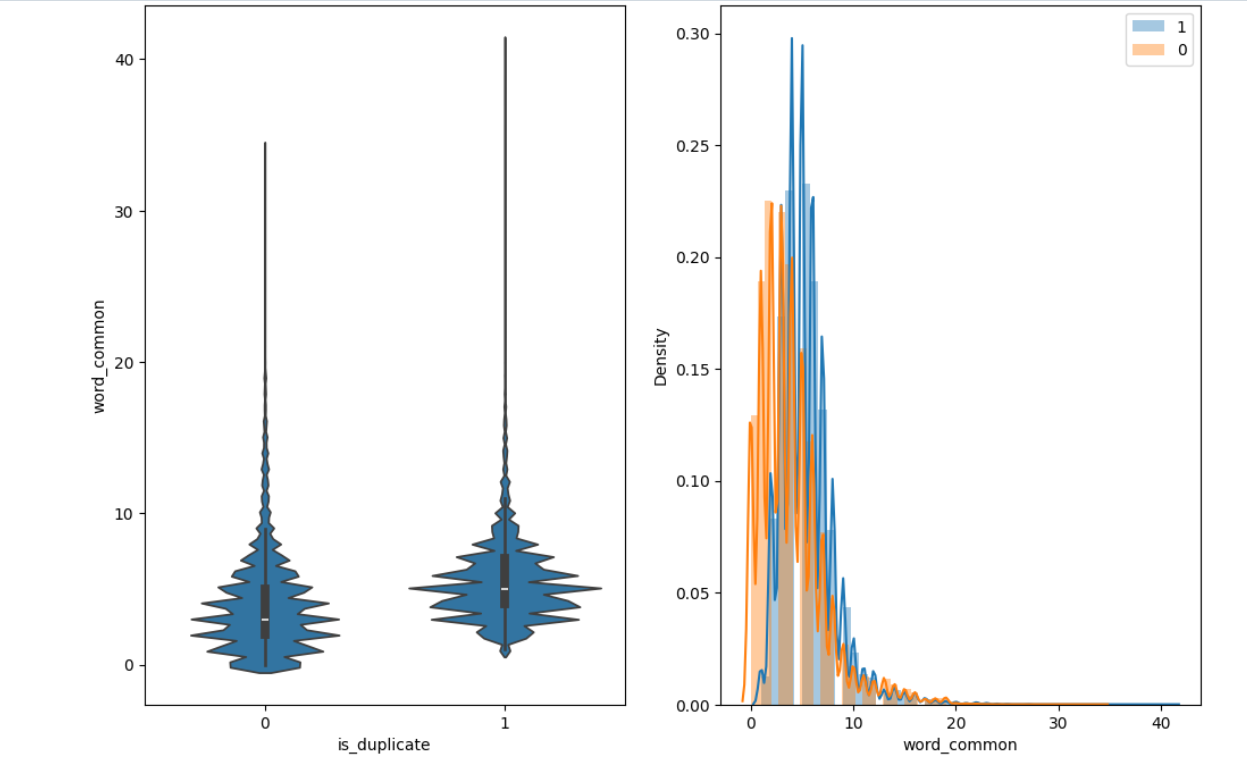

In [ ]:

import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import os
import re


import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


import plotly.offline as py
import plotly.graph_objs as go
py.init_notebook_mode(connected=True)

# NLP
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup

# Distance & fuzzy matching
import distance
from fuzzywuzzy import fuzz

# Machine learning
from sklearn.manifold import TSNE

# WordCloud
from wordcloud import WordCloud, STOPWORDS
from PIL import Image




In [ ]:
from wordcloud import WordCloud, STOPWORDS
from os import path
from PIL import Image
import os
import pandas as pd


if os.path.isfile('train.csv'):
    df = pd.read_csv('train.csv', encoding='latin-1')
    print("File loaded successfully")
else:
    print("File not found")


df.head()
df.head(2)


File not found


,id,qid1,qid2,question1,question2,is_duplicate,freq_qid1,freq_qid2,q1len,q2len,q1_n_words,q2_n_words,word_common,word_total,word_share,freq_q1+q2,freq_q1-q2
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,1,1,66,57,14,12,10.0,23.0,0.434783,2,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,4,1,51,88,8,13,4.0,20.0,0.200000,5,3



---

# **4. Text Preprocessing & Advanced Feature Extraction**

Raw text contains noise (HTML tags, punctuation) and variations (running vs. run). We clean this data first, then engineer advanced features to measure similarity.

### **4.1. Text Preprocessing**

Before analysis, we standardize the text:

1. **Remove HTML Tags:** Since Quora is a web platform, text often contains tags like `<b>`, `<br>`. We strip these out.
2. **Remove Punctuation:** Characters like `?`, `!`, `.` are removed as they don't define the core meaning.
3. **Stemming:** We reduce words to their root form (e.g., "running"  "run").
4. **Stopwords Removal:** We remove common words that carry little meaning (e.g., "the", "is", "and").
5. **Contraction Expansion:** We fix shortcuts (e.g., "don't"  "do not").
6. **Symbol Replacement:** We replace symbols with text (e.g., `%`  "percent", `$`  "dollar").

**Key Definitions:**

* **Token:** A single unit of text, usually a word (e.g., "running" is a token).
* **Stop Word:** A high-frequency word with low semantic value (e.g., "is", "the", "an").
* **Word:** In this context, a meaningful token that is not a stop word.

---

### **4.2. Advanced NLP Features (The "Ratios")**

We calculate mathematical ratios to quantify similarity.

* **`cwc_min` / `cwc_max`:** Ratio of common **words** to the length of the smaller/larger question.
Formula: $\frac{\text{Common Words}}{\min(\text{len}(q1), \text{len}(q2))}$
* **`csc_min` / `csc_max`:** Ratio of common **stop words** to the smaller/larger question.
* **`ctc_min` / `ctc_max`:** Ratio of common **tokens** (all words) to the smaller/larger question.
* **`last_word_eq`:** 1 if the last word of both questions is the same, else 0.
* **`first_word_eq`:** 1 if the first word of both questions is the same, else 0.
* **`abs_len_diff`:** Absolute difference in the number of tokens. $|len(q1) - len(q2)|$
* **`mean_len`:** Average length of the two questions. $\frac{len(q1) + len(q2)}{2}$

---

### **4.3. Fuzzy Features (Handling Typos & Ordering)**

Standard matching fails on typos or different word orders. We use **FuzzyWuzzy** (Levenstein Distance) to solve this.

1. **`fuzz_ratio` (Exact Similarity):**

* Calculates similarity based on the **Edit Distance** (minimum operations to turn String A into String B).
* *Example:* "Color" vs "Colour"  High Ratio (Good).
* *Limitation:* "Jaipur" vs "Raipur". The edit distance is small (1 letter change), so the ratio is high, but the meanings are completely different.

2. **`fuzz_partial_ratio` (Substring Matching):**

* Matches the best substring overlap.
* *Example:* "Hyderabad" vs "Hyderabad, Telangana". The ratio is 100% because the first word matches perfectly.
* *Limitation:* Fails on reordered sentences. "New York vs Atlanta" and "Atlanta vs New York" might look different.

3. **`token_sort_ratio` (Ordering Solution):**

* Tokenizes the sentence, **sorts the words alphabetically**, and then compares them.
* *Example:* "New York vs Atlanta"  "Atlanta New vs York". Now it matches "Atlanta vs New York" perfectly.

4. **`token_set_ratio` (Subset Solution):**

* This is the most powerful fuzzy feature for handling subset matches (e.g., "Jaipur" vs "Pink City Jaipur"). It breaks the sentences into three sets to isolate the common words from the unique words.
* **The Logic ():**
* First, we find the **Intersection** (words common to both) and the **Differences** (words unique to Q1 or Q2).
* We construct three string combinations:
* **:** The Intersection words (sorted).
* **:** Intersection words + Words unique to Q1.
* **:** Intersection words + Words unique to Q2.
* **The Calculation:** We calculate the `fuzz_ratio` for every pair of these combinations and take the maximum score:

1. `fuzz_ratio`()
2. `fuzz_ratio`()
3. `fuzz_ratio`()

* **Result:** `token_set_ratio = max(ratio1, ratio2, ratio3)`

5. **`longest_substr_ratio`:**

* Finds the length of the longest continuous common substring.
* Formula: $\frac{\text{Length of Longest Common Substring}}{\min(\text{len}(q1), \text{len}(q2))}$

---

### **4.4. Word Clouds**

A **Word Cloud** is a visualization technique where the size of each word indicates its frequency or importance. We use it to verify duplicate vs. non-duplicate vocabularies visually.

In [ ]:

SAFE_DIV = 0.0001


STOP_WORDS = stopwords.words("english")


def preprocess(x):

    x = str(x).lower()

    x = x.replace(",000,000", "m") \
         .replace(",000", "k") \
         .replace("n't", " not") \
         .replace("what's", "what is") \
         .replace("'ve", " have") \
         .replace("i'm", "i am") \
         .replace("he's", "he is") \
         .replace("she's", "she is") \
         .replace("%", " percent ") \
         .replace("₹", " rupee ") \
         .replace("€", " euro ") \
         .replace("'ll", " will ")

    x = re.sub(r"([0-9]+)000000", r"\1m", x)
    x = re.sub(r"([0-9]+)000", r"\1k", x)

    porter = PorterStemmer()
    pattern = re.compile(r'\W')

    if type(x) == type(""):
        x = re.sub(pattern, " ", x)

    if type(x) == type(1):
        x = porter.stem(str(x))

    example1 = BeautifulSoup(x, "lxml")
    x = example1.get_text()

    return x


In [ ]:
def get_token_features(q1, q2):

    token_features = [0.0] * 10

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features


In [ ]:
df_duplicate = df[df['is_duplicate'] == 1]
dfp_nonduplicate = df[df['is_duplicate'] == 0]

# Converting 2d array of q1 and q2 and flatten the array: like ((1,2),(3,4))

p = np.dstack([df_duplicate["question1"], df_duplicate["question2"]]).flatten()
n = np.dstack([dfp_nonduplicate["question1"], dfp_nonduplicate["question2"]]).flatten()

print("Number of data points in class 1 (duplicate pairs):", len(p))
print("Number of data points in class 0 (non duplicate pairs):", len(n))

# Saving the arrays into text files
np.savetxt('train_p.txt', p, delimiter=' ', fmt='%s', encoding='utf-8')
np.savetxt('train_n.txt', n, delimiter=' ', fmt='%s', encoding='utf-8')



Number of data points in class 1 (duplicate pairs): 298526
Number of data points in class 0 (non duplicate pairs): 510054


In [ ]:
from os import path

d = path.dirname('.')

textp_w = open(path.join(d, 'train_p.txt'), encoding='utf-8').read()
textn_w = open(path.join(d, 'train_n.txt'), encoding='utf-8').read()

stopwords = set(STOPWORDS)

stopwords.add("said")
stopwords.add("br")
stopwords.add("")

stopwords.remove("not")
stopwords.remove("no")

stopwords.remove("like")

print("Total number of words in duplicate pair questions:", len(textp_w))
print("Total number of words in non duplicate pair questions:", len(textn_w))


Total number of words in duplicate pair questions: 16087608
Total number of words in non duplicate pair questions: 33092279


Word Cloud for Duplicate Question pairs


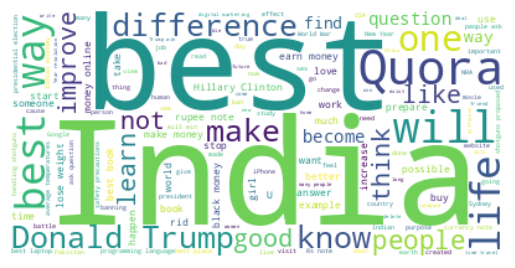

In [ ]:
wc = WordCloud(
    background_color="white",
    max_words=len(textp_w),
    stopwords=stopwords
)

wc.generate(textp_w)

print("Word Cloud for Duplicate Question pairs")

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()


Word Cloud for Non-Duplicate Question pairs


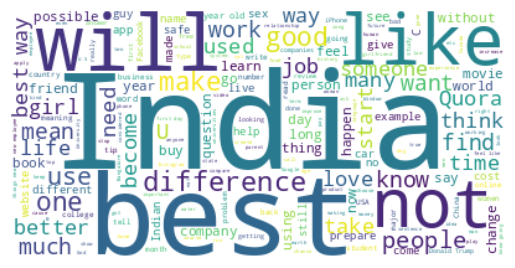

In [ ]:
wc = WordCloud(
    background_color="white",
    max_words=len(textn_w),
    stopwords=stopwords
)

wc.generate(textn_w)

print("Word Cloud for Non-Duplicate Question pairs")

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import time
import warnings
import numpy as np
from nltk.corpus import stopwords  # fixed: nitk → nltk
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")

import sys
import os
from tqdm import tqdm
import spacy



---

# **5. Featurizing Text Data with TF-IDF Weighted Word2Vec**

### **5.1. Why Vectorization?**

Machine Learning models (like XGBoost or Random Forest) are mathematical functions. They cannot understand raw text strings like "King" or "Queen." They only understand numbers.

* **The Goal:** We need to convert our text questions into numerical vectors while preserving their **semantic meaning**.

### **5.2. Word2Vec & Semantic Relationships**

We use **Word2Vec** (specifically the **GloVe** model via Spacy), which represents words as dense vectors in a high-dimensional space.

* **The Intuition:** Words that appear in similar contexts are placed closer together in this mathematical space.
* **Example:**
* Sentence A: *"The **King** sat on the throne."*
* Sentence B: *"The **Queen** sat on the throne."*
* Since "King" and "Queen" share almost identical contexts, the model learns they are semantically related. Their vectors will have a very high cosine similarity (close to 1).



### **5.3. Our Approach: TF-IDF Weighted Word2Vec**

We don't just take the average of all word vectors in a sentence. We use **TF-IDF Weighting**.

* **Why?** A word like "Apple" in *"Apple Inc. stock prices"* is very important. A word like "the" is not. Standard averaging would treat "Apple" and "the" equally.
* **The Solution:** We multiply each word's vector by its **TF-IDF score** (which measures rarity/importance) before averaging.

$$\text{Sentence Vector} = \frac{\sum (\text{Word Vector} \times \text{TF-IDF Score})}{\sum \text{TF-IDF Scores}}$$

Efficient Vectorization with spaCy nlp.pipe()

Processing hundreds of thousands of questions word-by-word using a standard Python for loop is extremely slow and computationally inefficient. A naïve loop would process one sentence at a time, resulting in significant overhead and execution times that can stretch to hours on large datasets like Quora Question Pairs.

To address this, we use spaCy’s nlp.pipe(), which processes texts in batches and leverages optimized Cython code under the hood.



### **5.4. Feature Analysis: Why 300 Dimensions?**

After vectorization, you will notice that `Question1` is now represented by **300 separate features** (`q1_w2v_0` to `q1_w2v_299`), and the same for `Question2`.

* **Why 300?** The GloVe model (`en_core_web_lg`) is trained on Wikipedia to represent every single word as a list of 300 numbers.
* **What do these numbers mean?** Each of the 300 dimensions captures a specific latent "concept" (e.g., dimension 5 might capture gender, dimension 42 might capture plurality, etc.).
* **No Dimensionality Reduction:** We do **not** use PCA to reduce these 300 dimensions down to 20 or 30. Doing so would destroy the rich semantic relationships the model has learned. We need all 300 to accurately represent the nuance of a question.

### **5.5. Visualization with t-SNE**

To visualize this 300-dimensional data, we use **t-SNE** (t-Distributed Stochastic Neighbor Embedding) to compress it into 2D.

* **Observation:** While there is some overlap (which is expected in difficult NLP tasks), we look for "islands" or clusters where duplicates (Class 1) separate from non-duplicates (Class 0). This confirms our features have predictive power.

### **5.6. Final Feature Vector**

Our final data structure (`df_final`) now contains a comprehensive set of inputs for our model:

1. **Basic Features:** `word_share`, `word_common`, lengths, frequencies.
2. **15 Advanced Features:** `cwc_min`, `fuzz_ratio`, `token_set_ratio`, etc.
3. **Q1 Semantics:** 300 TF-IDF Weighted Word2Vec features.
4. **Q2 Semantics:** 300 TF-IDF Weighted Word2Vec features.
5. **Target:** `is_duplicate`

---

In [ ]:
import pandas as pd
import numpy as np
from fuzzywuzzy import fuzz
import distance
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Define Feature Extraction Functions ---

def get_token_features(q1, q2):
    token_features = [0.0] * 10

    # Safe Division to avoid DivideByZero errors
    SAFE_DIV = 0.0001

    q1_tokens = str(q1).split()
    q2_tokens = str(q2).split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get Stopwords (using NLTK's list you imported earlier or a simple set)
    STOP_WORDS = set(['the', 'a', 'an', 'is', 'are', 'in', 'of', 'to', 'and', 'for', 'on'])

    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    common_word_count = len(q1_words.intersection(q2_words))
    common_stop_count = len(q1_stops.intersection(q2_stops))
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    # Calculating features
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    token_features[8] = abs(len(q1_tokens) - len(q2_tokens))
    token_features[9] = (len(q1_tokens) + len(q2_tokens)) / 2
    return token_features

def get_longest_substr_ratio(a, b):
    strs = list(distance.lcsubstrings(a, b))
    if len(strs) == 0:
        return 0
    return len(strs[0]) / (min(len(a), len(b)) + 1)

# --- 2. Apply Functions to DataFrame ---
print("Generating Advanced Features... (This may take a few minutes)")

# Apply Token Features
token_features = df.apply(lambda x: get_token_features(x["question1"], x["question2"]), axis=1)

df["cwc_min"] = list(map(lambda x: x[0], token_features))
df["cwc_max"] = list(map(lambda x: x[1], token_features))
df["csc_min"] = list(map(lambda x: x[2], token_features))
df["csc_max"] = list(map(lambda x: x[3], token_features))
df["ctc_min"] = list(map(lambda x: x[4], token_features))
df["ctc_max"] = list(map(lambda x: x[5], token_features))
df["last_word_eq"] = list(map(lambda x: x[6], token_features))
df["first_word_eq"] = list(map(lambda x: x[7], token_features))
df["abs_len_diff"] = list(map(lambda x: x[8], token_features))
df["mean_len"] = list(map(lambda x: x[9], token_features))

# Apply Fuzzy Features
print("Calculating Fuzzy Features...")
df["token_sort_ratio"] = df.apply(lambda x: fuzz.token_sort_ratio(str(x["question1"]), str(x["question2"])), axis=1)
df["token_set_ratio"] = df.apply(lambda x: fuzz.token_set_ratio(str(x["question1"]), str(x["question2"])), axis=1)
df["fuzz_ratio"] = df.apply(lambda x: fuzz.QRatio(str(x["question1"]), str(x["question2"])), axis=1)
df["fuzz_partial_ratio"] = df.apply(lambda x: fuzz.partial_ratio(str(x["question1"]), str(x["question2"])), axis=1)
df["longest_substr_ratio"] = df.apply(lambda x: get_longest_substr_ratio(str(x["question1"]), str(x["question2"])), axis=1)

print("Feature Extraction Complete!")

Generating Advanced Features... (This may take a few minutes)
Calculating Fuzzy Features...
Feature Extraction Complete!


Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.019s...
[t-SNE] Computed neighbors for 5000 samples in 0.612s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.108222
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.998390
[t-SNE] KL divergence after 1000 iterations: 0.807645


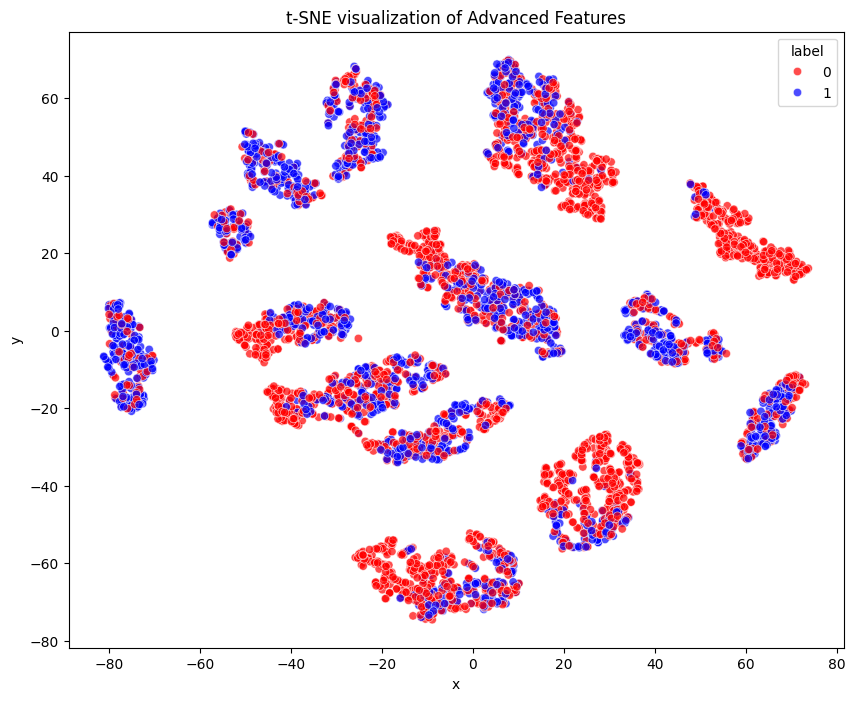

Calculating TF-IDF Weighted Word2Vec...


100%|██████████| 404290/404290 [07:52<00:00, 855.52it/s] 


Vectorization Complete. Shapes: (404290, 96) (404290, 96)


In [ ]:
# --- 3. t-SNE Visualization ---
print("Running t-SNE...")
# Using a subset (first 5000 rows)
df_subsampled = df[0:5000]

feature_cols = ['cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min', 'ctc_max',
                'last_word_eq', 'first_word_eq', 'abs_len_diff', 'mean_len',
                'token_set_ratio', 'token_sort_ratio', 'fuzz_ratio',
                'fuzz_partial_ratio', 'longest_substr_ratio']

# Scale the data first
X = MinMaxScaler().fit_transform(df_subsampled[feature_cols])
y = df_subsampled['is_duplicate'].values

# Run t-SNE
tsne2d = TSNE(
    n_components=2,
    init='random',
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=1,
    perplexity=30,
    angle=0.5
).fit_transform(X)


tsne_df = pd.DataFrame({'x': tsne2d[:, 0], 'y': tsne2d[:, 1], 'label': y})
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='x', y='y', hue='label', palette=["red", "blue"], alpha=0.7)
plt.title("t-SNE visualization of Advanced Features")
plt.show()

# --- 4. Efficient TF-IDF Weighted Word2Vec ---
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm

print("Calculating TF-IDF Weighted Word2Vec...")

# Load Spacy model (ensure you have run: python -m spacy download en_core_web_sm)
try:
    nlp = spacy.load("en_core_web_sm")
except:
    print("Downloading Spacy model...")
    import subprocess
    subprocess.call(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load("en_core_web_sm")

# 1. Fit TF-IDF
questions = list(df['question1']) + list(df['question2'])
tfidf = TfidfVectorizer(lowercase=False)
tfidf.fit(questions)
word2tfidf = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

# 2. Efficient Vectorizer Function
def get_weighted_vectors(docs, nlp, word2tfidf, vec_dim=96):
    vecs = []
    # nlp.pipe processes in batches, which is much faster than a standard loop
    for doc in tqdm(nlp.pipe(docs, batch_size=200, disable=["parser", "ner"]), total=len(docs)):
        mean_vec = np.zeros(vec_dim)
        if len(doc) == 0:
            vecs.append(mean_vec)
            continue

        weight_sum = 0
        for word in doc:
            vec = word.vector
            # If word is in our dictionary, use its IDF score, else 0
            idf = word2tfidf.get(str(word), 0)
            mean_vec += vec * idf
            weight_sum += idf

        if weight_sum != 0:
            mean_vec /= weight_sum
        vecs.append(mean_vec)
    return np.array(vecs)

# Compute vectors
q1_w2v = get_weighted_vectors(df['question1'].astype(str).values, nlp, word2tfidf)
q2_w2v = get_weighted_vectors(df['question2'].astype(str).values, nlp, word2tfidf)

print("Vectorization Complete. Shapes:", q1_w2v.shape, q2_w2v.shape)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Define the list of all scalar feature columns (Basic + Advanced)

scalar_features = [
    # Basic Features
    'freq_qid1', 'freq_qid2', 'q1len', 'q2len', 'q1_n_words', 'q2_n_words',
    'word_common', 'word_total', 'word_share', 'freq_q1+q2', 'freq_q1-q2',

    # Advanced Features
    'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min', 'ctc_max',
    'last_word_eq', 'first_word_eq', 'abs_len_diff', 'mean_len',
    'token_set_ratio', 'token_sort_ratio', 'fuzz_ratio', 'fuzz_partial_ratio', 'longest_substr_ratio'
]

# 2. Extract and Scale Scalar Features
print("Scaling scalar features...")
# Using MinMaxScaler to normalize features to range [0, 1]
X_scalars = MinMaxScaler().fit_transform(df[scalar_features])

# 3. Stack Everything Together
# Structure: [Scalar Features, Question1 Vectors, Question2 Vectors]
print("Stacking features...")
X_final = np.hstack((X_scalars, q1_w2v, q2_w2v))
y_final = df['is_duplicate'].values

print(f"Final Data Matrix Shape: {X_final.shape}")

# 4. Train/Test Split (70:30)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, stratify=y_final, test_size=0.3, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Scaling scalar features...
Stacking features...
Final Data Matrix Shape: (404290, 218)
Train shape: (283003, 218)
Test shape: (121287, 218)




---

# **6. Model Building & Evaluation**

We train multiple models, starting from a "dumb" baseline to advanced gradient boosting, to benchmark our performance.

### **6.3. Model Progression**

#### **A. Random Model (The Baseline)**

* **Concept:** We generate random probabilities for .
* **Result:** **Log Loss  0.88**. This is our "worst-case scenario."
* **Matrix Analysis:** The Precision Matrix typically shows values near the class imbalance (~0.37 for Class 1), proving the model has zero predictive power.

#### **B. Linear Models (SGDClassifier)**

We use **Stochastic Gradient Descent (SGD)** to train efficient linear models.

1. **Logistic Regression:** Optimizes **Log Loss** with L2 regularization.
2. **Linear SVM:** Optimizes **Hinge Loss** with L2 regularization.
* *Note:* SVM outputs distances, not probabilities. We use `CalibratedClassifierCV` (Sigmoid calibration) to convert these distances into the probabilities required for Log Loss.



#### **C. XGBoost (Gradient Boosting)**

Finally, we use **XGBoost**, a non-linear tree-based model.

* **Why:** Linear models fail to capture complex interactions (e.g., "If `token_sort_ratio` is high BUT `word_common` is low..."). XGBoost handles these non-linear relationships.
* **Final Result:** XGBoost achieves the best performance with a **Log Loss of 0.363**.

**Visualizing the Improvements (Confusion Matrix Analysis):**
As seen in the results, the model has learned significant patterns:

1. **Diagonal Dominance (Confusion Matrix):**
* The "Diagonal" values (Top-Left and Bottom-Right) represent correct predictions.
* We correctly identified **68,133** Non-Duplicates (Class 0) and **31,361** Duplicates (Class 1).
* Compare this to the off-diagonal errors (only ~8k False Positives and ~13k False Negatives), showing the model is correct the vast majority of the time.


2. **Precision & Recall Surge:**
* **Precision (Class 1):** The Random Model had a precision of ~0.37. XGBoost improved this to **0.789**. This means when XGBoost says "It's a duplicate," it is correct **78.9%** of the time.
* **Recall (Class 1):** The Recall is **0.700**, meaning the model successfully finds **70%** of all real duplicates in the dataset.

Splitting data...
Train shape: (283003, 218) Test shape: (121287, 218)

1. Random Model (Baseline)
Log loss on Test Data using Random Model 0.8833500851664378


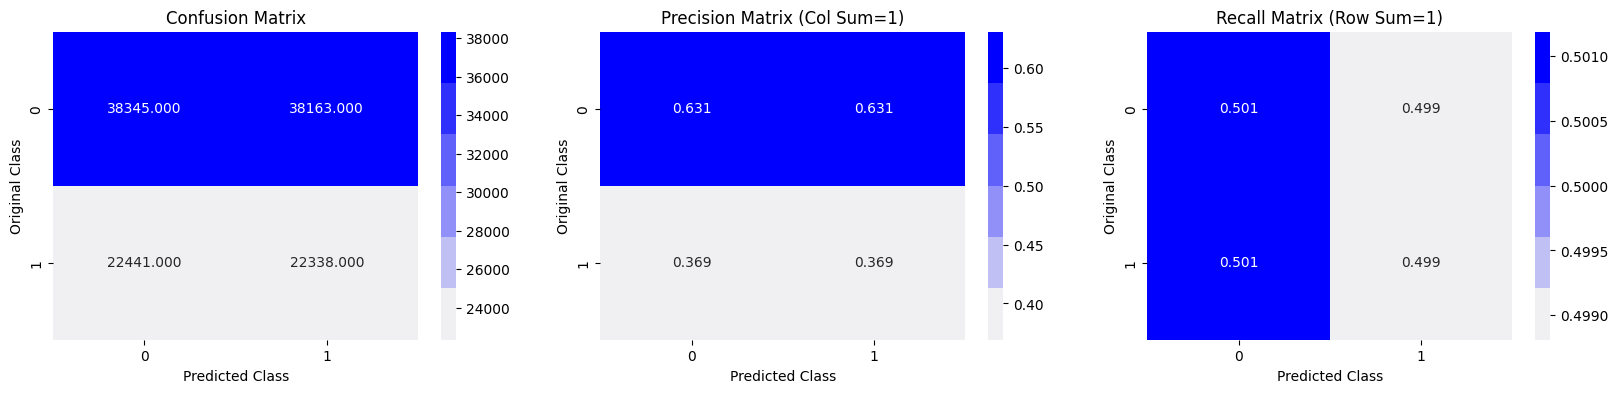


2. Logistic Regression (Linear with Log Loss)
Log loss for Logistic Regression: 0.5096438723776103


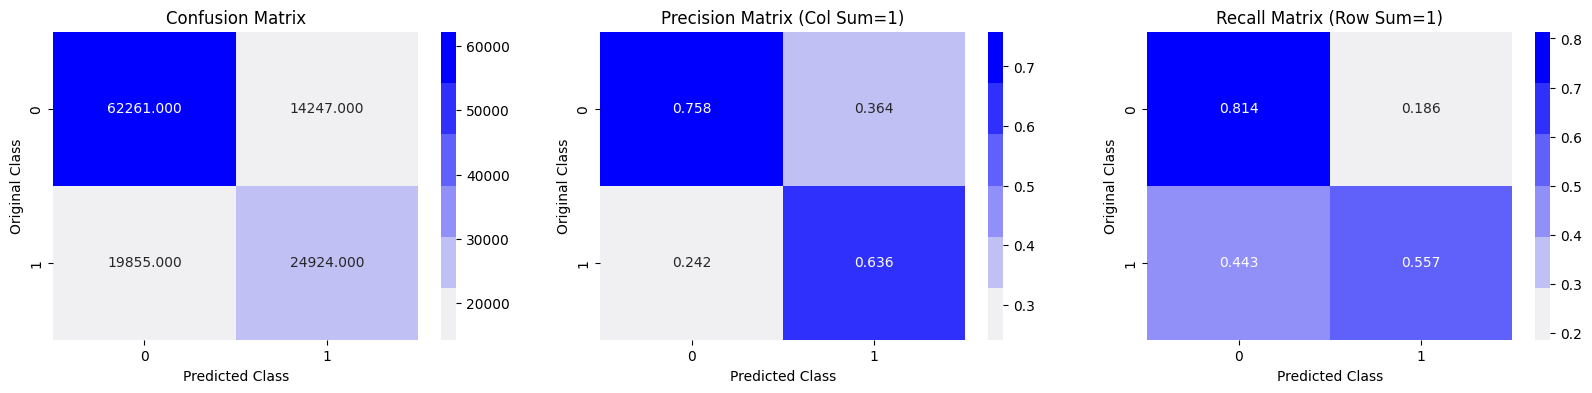


3. Linear SVM (Linear with Hinge Loss)
Log loss for Linear SVM: 0.5024948024128956


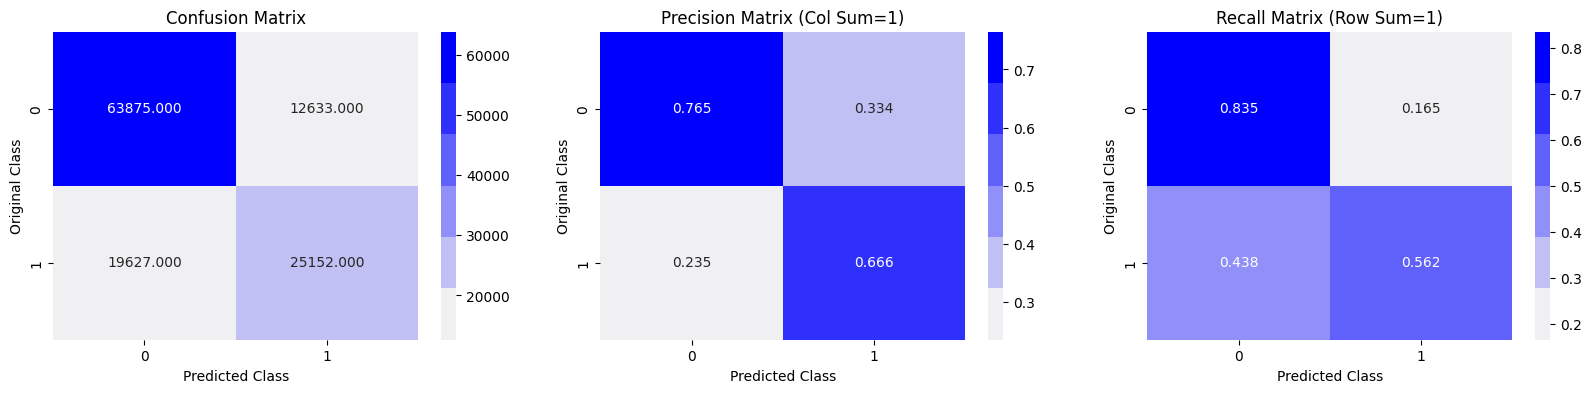


4. XGBoost
[0]	train-logloss:0.65128	valid-logloss:0.65124
[50]	train-logloss:0.47083	valid-logloss:0.46970
[100]	train-logloss:0.41694	valid-logloss:0.41566
[150]	train-logloss:0.39465	valid-logloss:0.39349
[200]	train-logloss:0.38374	valid-logloss:0.38283
[250]	train-logloss:0.37635	valid-logloss:0.37581
[300]	train-logloss:0.37075	valid-logloss:0.37053
[350]	train-logloss:0.36645	valid-logloss:0.36659
[399]	train-logloss:0.36284	valid-logloss:0.36334
Log loss for XGBoost: 0.36333547044772746


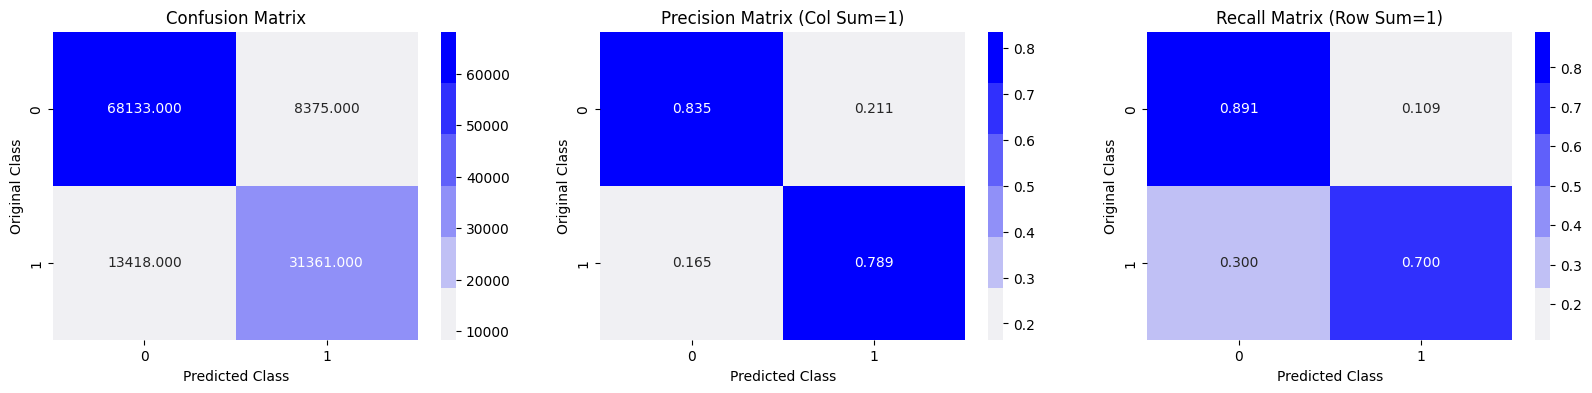

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, log_loss
import xgboost as xgb

def plot_confusion_matrix(test_y, predict_y):
    C = confusion_matrix(test_y, predict_y)

    # Precision Matrix (Col-wise normalization)

    A = (((C.T)/(C.sum(axis=1))).T)

    # Recall Matrix (Row-wise normalization)
    B = (C/C.sum(axis=0))

    plt.figure(figsize=(20, 4))

    labels = [0, 1]  # 0: Non-Duplicate, 1: Duplicate
    cmap = sns.light_palette("blue")

    # --- Plot 1: Confusion Matrix ---
    plt.subplot(1, 3, 1)
    sns.heatmap(C, annot=True, cmap=cmap, fmt=".3f", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Class')
    plt.ylabel('Original Class')
    plt.title("Confusion Matrix")

    # --- Plot 2: Precision Matrix ---
    plt.subplot(1, 3, 2)
    sns.heatmap(B, annot=True, cmap=cmap, fmt=".3f", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Class')
    plt.ylabel('Original Class')
    plt.title("Precision Matrix (Col Sum=1)")

    # --- Plot 3: Recall Matrix ---
    plt.subplot(1, 3, 3)
    sns.heatmap(A, annot=True, cmap=cmap, fmt=".3f", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Class')
    plt.ylabel('Original Class')
    plt.title("Recall Matrix (Row Sum=1)")

    plt.show()

# --- 2. Robust Log Loss Function
def safe_log_loss(y_true, y_pred):
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return log_loss(y_true, y_pred_clipped)

# --- 3. Train-Test Split ---

if 'X_final' in locals() and 'y_final' in locals():
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, stratify=y_final, test_size=0.3, random_state=42)
    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
else:
    print("Error: X_final and y_final not found. Please run the previous feature combination code first.")

# =============================================================================
# MODEL 1: Random Model (Baseline)
# =============================================================================
print("\n" + "="*50)
print("1. Random Model (Baseline)")
print("="*50)

# Generate random probabilities that sum to 1
predicted_y = np.zeros((len(y_test), 2))
for i in range(len(y_test)):
    rand_probs = np.random.rand(1, 2)
    predicted_y[i] = ((rand_probs / sum(sum(rand_probs)))[0])

print("Log loss on Test Data using Random Model", safe_log_loss(y_test, predicted_y))

# Plot Matrices (using threshold 0.5 for classification)
plot_confusion_matrix(y_test, np.argmax(predicted_y, axis=1))


# =============================================================================
# MODEL 2: Logistic Regression
# =============================================================================
print("\n" + "="*50)
print("2. Logistic Regression (Linear with Log Loss)")
print("="*50)

alpha = 0.01
clf = SGDClassifier(alpha=alpha, penalty='l2', loss='log_loss', random_state=42)
clf.fit(X_train, y_train)
# Calibrate for probabilities
sig_clf = CalibratedClassifierCV(clf, method="sigmoid")
sig_clf.fit(X_train, y_train)

predict_y = sig_clf.predict_proba(X_test)
print("Log loss for Logistic Regression:", safe_log_loss(y_test, predict_y))

plot_confusion_matrix(y_test, sig_clf.predict(X_test))


# =============================================================================
# MODEL 3: Linear SVM
# =============================================================================
print("\n" + "="*50)
print("3. Linear SVM (Linear with Hinge Loss)")
print("="*50)

# SVM uses hinge loss
clf = SGDClassifier(alpha=alpha, penalty='l2', loss='hinge', random_state=42)
clf.fit(X_train, y_train)
# Calibrate for probabilities
sig_clf = CalibratedClassifierCV(clf, method="sigmoid")
sig_clf.fit(X_train, y_train)

predict_y = sig_clf.predict_proba(X_test)
print("Log loss for Linear SVM:", safe_log_loss(y_test, predict_y))

plot_confusion_matrix(y_test, sig_clf.predict(X_test))


# =============================================================================
# MODEL 4: XGBoost
# =============================================================================
print("\n" + "="*50)
print("4. XGBoost")
print("="*50)

d_train = xgb.DMatrix(X_train, label=y_train)
d_test = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.02,
    'max_depth': 4,
}

watchlist = [(d_train, 'train'), (d_test, 'valid')]
bst = xgb.train(params, d_train, num_boost_round=400, evals=watchlist, early_stopping_rounds=20, verbose_eval=50)

xg_predict_y = bst.predict(d_test)
print("Log loss for XGBoost:", safe_log_loss(y_test, xg_predict_y))

# XGBoost outputs probabilities, so we check if prob > 0.5
predicted_classes = np.array(xg_predict_y > 0.5, dtype=int)
plot_confusion_matrix(y_test, predicted_classes)